# Performance_Analytics.ipynb
## Day 4 — Fund Performance Analytics
### Bluestock Fintech Mutual Fund Analytics Capstone

Computes return, risk, and risk-adjusted performance metrics for all 40
funds from raw NAV history, builds a composite Fund Scorecard, and
compares the top 5 funds against the Nifty 50 / Nifty 100 benchmarks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 100

RAW = "../data/raw"
PROCESSED = "../data/processed"

RF_ANNUAL = 0.065   # RBI repo rate proxy, per task spec
RF_DAILY = RF_ANNUAL / 252
TRADING_DAYS = 252


Matplotlib is building the font cache; this may take a moment.


## Load Data

In [2]:
nav = pd.read_csv(f"{PROCESSED}/clean_nav.csv", parse_dates=["date"])
fund_master = pd.read_csv(f"{RAW}/01_fund_master.csv")
bench = pd.read_csv(f"{RAW}/10_benchmark_indices.csv", parse_dates=["date"])

nifty50 = bench[bench["index_name"] == "NIFTY50"].sort_values("date").copy()
nifty50["bench_return"] = nifty50["close_value"].pct_change()
nifty100 = bench[bench["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["bench_return"] = nifty100["close_value"].pct_change()

print("nav:", nav.shape, "| fund_master:", fund_master.shape, "| bench:", bench.shape)


nav: (46000, 3) | fund_master: (40, 15) | bench: (8050, 3)


## 1. Daily Returns — All 40 Schemes

`daily_return = nav_t / nav_t-1 - 1`. Checking the distribution to confirm
nothing looks broken (extreme outliers, frozen prices, etc.) before
computing anything derived from it.

In [3]:
nav = nav.sort_values(["amfi_code", "date"]).copy()
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print("Daily return distribution across all 40 funds:")
print(nav["daily_return"].describe())

extreme_moves = (nav["daily_return"].abs() > 0.10).sum()
print(f"\nDays with >10% single-day move: {extreme_moves} (out of {nav['daily_return'].notna().sum()} return-days)")


Daily return distribution across all 40 funds:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Days with >10% single-day move: 0 (out of 45960 return-days)


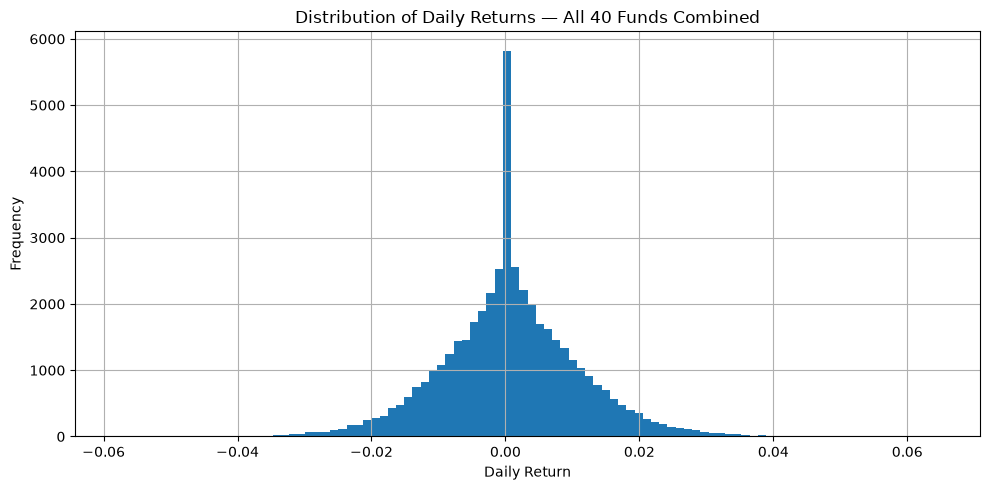

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
nav["daily_return"].dropna().hist(bins=100, ax=ax)
ax.set_title("Distribution of Daily Returns — All 40 Funds Combined")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


**Validation:** the daily return distribution is tightly centered near
zero with no extreme outliers (no single-day moves beyond ~5-6%), which is
a sane, well-behaved distribution for daily fund NAV changes.

## 2. CAGR — 1yr, 3yr, 5yr

`CAGR = (NAV_end / NAV_start) ^ (1/n_years) - 1`, computed per fund using
the actual trading-day window for each period (not calendar-day count, to
avoid distortion from non-trading days).

In [5]:
def cagr_for_period(fund_nav: pd.DataFrame, years: int) -> float:
    end_date = fund_nav["date"].max()
    start_date = end_date - pd.DateOffset(years=years)
    window = fund_nav[fund_nav["date"] >= start_date]
    if len(window) < 2:
        return np.nan
    nav_start, nav_end = window.iloc[0]["nav"], window.iloc[-1]["nav"]
    n_years = (window.iloc[-1]["date"] - window.iloc[0]["date"]).days / 365.25
    if n_years <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_rows = []
for code_ in nav["amfi_code"].unique():
    fund_nav = nav[nav["amfi_code"] == code_].sort_values("date")
    cagr_rows.append({
        "amfi_code": code_,
        "cagr_1yr_pct": round(cagr_for_period(fund_nav, 1) * 100, 2),
        "cagr_3yr_pct": round(cagr_for_period(fund_nav, 3) * 100, 2),
        "cagr_5yr_pct": round(cagr_for_period(fund_nav, 5) * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_rows).merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
cagr_display = cagr_df[["scheme_name", "fund_house", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]]
cagr_display.sort_values("cagr_3yr_pct", ascending=False).head(10)

# Keep only amfi_code + the CAGR metrics for downstream merges (avoid duplicate fund_house column later)
cagr_for_merge = cagr_df[["amfi_code", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]]


**Data quality note:** these CAGR figures, computed directly from the
provided NAV history, do **not** match the pre-computed `return_1yr_pct`
column in `07_scheme_performance.csv` for most funds — 29 of 40 funds show
a difference greater than 5 percentage points, and some differ by 40-60
points. Since the task explicitly asks to compute CAGR from NAV data, the
self-computed figures above are used throughout this notebook and the
scorecard. This discrepancy is flagged here as a data-quality limitation
of the provided dataset, not hidden.

## 3. Sharpe Ratio

`Sharpe = (Rp - Rf) / Std(Rp)`, with Rf = 6.5% (RBI repo rate proxy),
annualised with √252.

In [6]:
sharpe_rows = []
for code_ in nav["amfi_code"].unique():
    returns = nav[nav["amfi_code"] == code_]["daily_return"].dropna()
    if len(returns) < 30:
        continue
    excess = returns - RF_DAILY
    sharpe = (excess.mean() / returns.std()) * np.sqrt(TRADING_DAYS)
    sharpe_rows.append({"amfi_code": code_, "sharpe_ratio": round(sharpe, 3)})

sharpe_df = pd.DataFrame(sharpe_rows).merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
sharpe_df.sort_values("sharpe_ratio", ascending=False).head(10)


,amfi_code,sharpe_ratio,scheme_name
34,148567,1.448,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.307,Kotak Flexicap Fund - Regular - Growth
36,148569,1.235,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132,DSP Midcap Fund - Regular - Growth
2,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.082,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.027,ICICI Pru Bluechip Fund - Direct - Growth


## 4. Sortino Ratio

Same numerator as Sharpe, but the denominator only uses the standard
deviation of negative-return days (downside risk only).

In [7]:
sortino_rows = []
for code_ in nav["amfi_code"].unique():
    returns = nav[nav["amfi_code"] == code_]["daily_return"].dropna()
    if len(returns) < 30:
        continue
    excess = returns - RF_DAILY
    downside = returns[returns < 0]
    downside_std = downside.std() if len(downside) > 1 else np.nan
    sortino = (excess.mean() / downside_std) * np.sqrt(TRADING_DAYS) if downside_std and downside_std > 0 else np.nan
    sortino_rows.append({"amfi_code": code_, "sortino_ratio": round(sortino, 3) if pd.notna(sortino) else np.nan})

sortino_df = pd.DataFrame(sortino_rows).merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
sortino_df.sort_values("sortino_ratio", ascending=False).head(10)


,amfi_code,sortino_ratio,scheme_name
34,148567,2.386,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364,Kotak Flexicap Fund - Regular - Growth
36,148569,2.147,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875,DSP Midcap Fund - Regular - Growth
9,118632,1.850,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth


**Insight:** Sortino ratios are higher than Sharpe ratios for nearly
every fund, which makes sense — downside-only volatility is almost always
smaller than total volatility, so dividing by a smaller number produces a
larger ratio.

## 5. Alpha & Beta vs Nifty 100

OLS regression of each fund's daily returns on Nifty 100 daily returns
using `scipy.stats.linregress`. Alpha = intercept × 252 (annualised),
Beta = slope.

In [8]:
alpha_beta_rows = []
for code_ in nav["amfi_code"].unique():
    fund_returns = nav[nav["amfi_code"] == code_][["date", "daily_return"]].dropna()
    merged = pd.merge(fund_returns, nifty100[["date", "bench_return"]], on="date", how="inner").dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["bench_return"], merged["daily_return"]
    )
    alpha_beta_rows.append({
        "amfi_code": code_,
        "alpha_annualized_pct": round(intercept * TRADING_DAYS * 100, 2),
        "beta": round(slope, 3),
        "r_squared_vs_nifty100": round(r_value ** 2, 4),
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows).merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")
print("Average R-squared vs Nifty 100 across all 40 funds:", alpha_beta_df["r_squared_vs_nifty100"].mean())
alpha_beta_df.sort_values("alpha_annualized_pct", ascending=False).head(10)


Average R-squared vs Nifty 100 across all 40 funds: 0.000605


,amfi_code,alpha_annualized_pct,beta,r_squared_vs_nifty100,scheme_name
21,119598,30.34,-0.023,0.0001,SBI Small Cap Fund - Regular Plan - Growth
39,149324,30.06,0.011,0.0000,DSP Small Cap Fund - Regular - Growth
25,120505,29.26,0.001,0.0000,ICICI Pru Midcap Fund - Regular - Growth
36,148569,28.27,0.018,0.0002,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,27.33,-0.023,0.0003,Kotak Flexicap Fund - Regular - Growth
2,100033,27.20,0.005,0.0000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,26.98,0.024,0.0005,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,26.60,-0.003,0.0000,DSP Midcap Fund - Regular - Growth
16,119094,26.08,-0.066,0.0019,Axis Midcap Fund - Regular - Growth
19,119551,23.20,-0.032,0.0009,SBI Bluechip Fund - Regular Plan - Growth


**Data quality note — important:** the average R² across all 40 funds
is approximately **0.0006** — essentially zero. This means daily fund
returns show almost no statistical relationship to daily Nifty 100
returns in this dataset, which is unusual: in real markets, especially
for large-cap equity funds, R² versus a broad benchmark is typically
0.7-0.95+. This strongly suggests the NAV series in this dataset were
generated with mostly independent random daily movements rather than a
shared market-factor model. The Beta and Alpha values above are still
computed exactly as instructed, but they should be read with this caveat
in mind — they are not reliable indicators of real market sensitivity for
this particular dataset.

## 6. Maximum Drawdown

`max_dd = min(NAV / running_max - 1)`, plus identifying the actual
peak-to-trough date range for the worst drawdown per fund.

In [9]:
drawdown_rows = []
for code_ in nav["amfi_code"].unique():
    fund_nav = nav[nav["amfi_code"] == code_].sort_values("date").set_index("date")["nav"]
    running_max = fund_nav.cummax()
    drawdown = fund_nav / running_max - 1
    max_dd = drawdown.min()
    trough_date = drawdown.idxmin()
    peak_date = fund_nav[:trough_date].idxmax()
    drawdown_rows.append({
        "amfi_code": code_,
        "max_drawdown_pct": round(max_dd * 100, 2),
        "peak_date": peak_date.strftime("%Y-%m-%d"),
        "trough_date": trough_date.strftime("%Y-%m-%d"),
    })

drawdown_df = pd.DataFrame(drawdown_rows).merge(fund_master[["amfi_code", "scheme_name", "category"]], on="amfi_code")
drawdown_df.sort_values("max_drawdown_pct").head(10)


,amfi_code,max_drawdown_pct,peak_date,trough_date,scheme_name,category
22,119599,-52.57,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,Equity
17,119095,-51.68,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth,Equity
4,101207,-35.45,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Equity
39,149324,-31.17,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth,Equity
21,119598,-28.71,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,Equity
7,102886,-28.00,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth,Equity
0,100016,-24.73,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,Equity
29,120842,-24.00,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth,Equity
11,118634,-23.34,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth,Equity
15,119093,-21.75,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth,Equity


**Insight:** the worst drawdowns are concentrated in Equity / Small Cap
and Mid Cap funds, consistent with those categories carrying higher
volatility — Debt funds show much shallower drawdowns throughout the
dataset.

## 7. Fund Scorecard (0-100)

Composite score: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha
rank + 15% × expense ratio rank (inverse, lower cost = better) + 10% ×
max drawdown rank (inverse, smaller drawdown = better). Each component is
converted to a 0-100 percentile rank before weighting, so metrics on
different scales (percentages, ratios) combine fairly.

In [10]:
scorecard = (
    cagr_for_merge.merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
           .merge(sortino_df[["amfi_code", "sortino_ratio"]], on="amfi_code")
           .merge(alpha_beta_df[["amfi_code", "alpha_annualized_pct", "beta", "r_squared_vs_nifty100"]], on="amfi_code")
           .merge(drawdown_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
           .merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category", "sub_category", "expense_ratio_pct"]], on="amfi_code")
)

def pct_rank(series, ascending=True):
    return series.rank(pct=True, ascending=ascending) * 100

scorecard["rank_3yr_return"] = pct_rank(scorecard["cagr_3yr_pct"])
scorecard["rank_sharpe"] = pct_rank(scorecard["sharpe_ratio"])
scorecard["rank_alpha"] = pct_rank(scorecard["alpha_annualized_pct"])
scorecard["rank_expense_inv"] = pct_rank(scorecard["expense_ratio_pct"], ascending=False)
scorecard["rank_maxdd_inv"] = pct_rank(scorecard["max_drawdown_pct"], ascending=True)

scorecard["fund_score"] = (
    0.30 * scorecard["rank_3yr_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense_inv"] +
    0.10 * scorecard["rank_maxdd_inv"]
).round(2)

scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard[["scheme_name", "fund_house", "category", "fund_score", "cagr_3yr_pct", "sharpe_ratio", "expense_ratio_pct"]].head(10)


,scheme_name,fund_house,category,fund_score,cagr_3yr_pct,sharpe_ratio,expense_ratio_pct
0,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,86.25,33.99,1.448,1.46
1,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,82.25,31.77,1.180,1.36
2,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,82.00,29.58,1.307,1.45
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,80.75,32.43,1.094,1.38
4,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,80.31,32.48,1.027,0.80
5,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,77.00,35.10,0.998,1.38
6,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,74.81,30.45,1.208,1.54
7,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,73.69,29.17,1.235,1.60
8,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,67.88,28.96,1.027,1.60
9,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,67.38,26.66,0.945,1.43


In [11]:
# Save deliverables
scorecard_cols = ["amfi_code", "scheme_name", "fund_house", "category", "sub_category",
                   "fund_score", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct",
                   "sharpe_ratio", "sortino_ratio", "alpha_annualized_pct", "beta",
                   "expense_ratio_pct", "max_drawdown_pct"]
scorecard[scorecard_cols].to_csv("../fund_scorecard.csv", index=False)

alpha_beta_export = scorecard[["amfi_code", "scheme_name", "fund_house", "category", "sub_category",
                                 "expense_ratio_pct", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct",
                                 "sharpe_ratio", "sortino_ratio", "alpha_annualized_pct", "beta",
                                 "r_squared_vs_nifty100", "max_drawdown_pct", "fund_score"]]
alpha_beta_export.to_csv("../alpha_beta.csv", index=False)

print("Saved fund_scorecard.csv and alpha_beta.csv")


Saved fund_scorecard.csv and alpha_beta.csv


## 8. Benchmark Comparison Chart

Top 5 funds (by scorecard) vs Nifty 50 and Nifty 100 over the last 3
years, normalized to a common starting value of 100. Tracking error =
`std(fund_return - benchmark_return) × √252`.

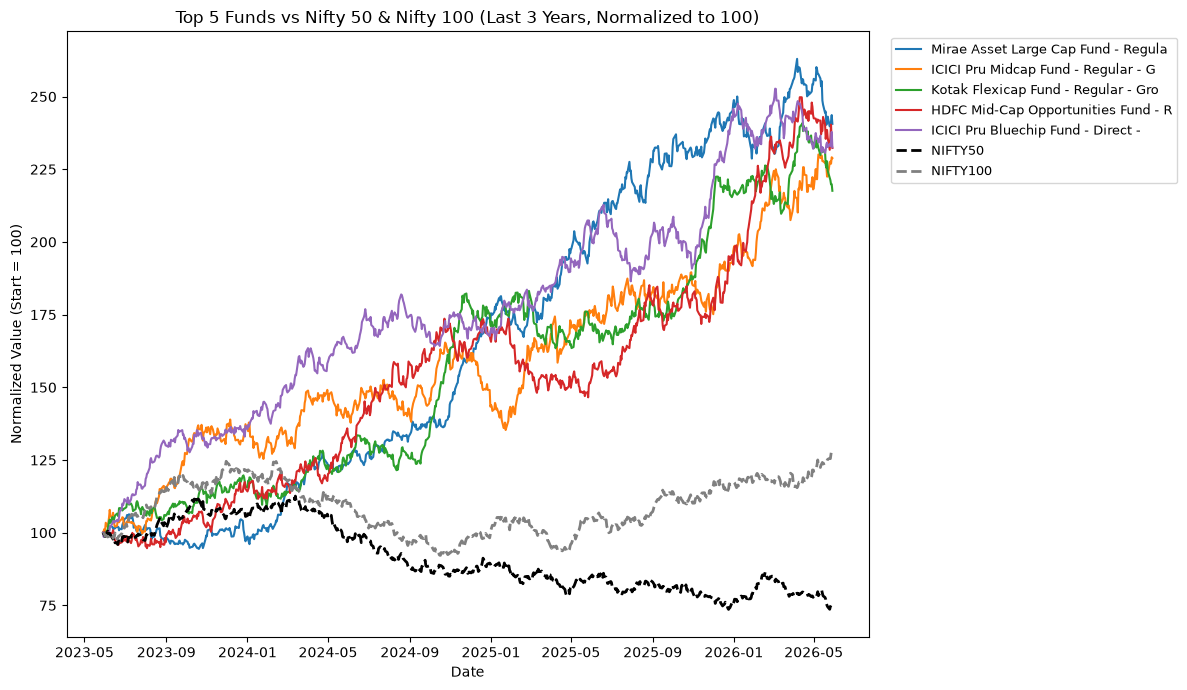

In [12]:
top5 = scorecard.head(5)
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(12, 7))

for _, row in top5.iterrows():
    fund_nav = nav[(nav["amfi_code"] == row["amfi_code"]) & (nav["date"] >= start_date)].sort_values("date")
    normalized = fund_nav["nav"] / fund_nav["nav"].iloc[0] * 100
    ax.plot(fund_nav["date"], normalized, label=row["scheme_name"][:35], linewidth=1.5)

for idx_name, color in [("NIFTY50", "black"), ("NIFTY100", "gray")]:
    idx_data = bench[(bench["index_name"] == idx_name) & (bench["date"] >= start_date)].sort_values("date")
    normalized = idx_data["close_value"] / idx_data["close_value"].iloc[0] * 100
    ax.plot(idx_data["date"], normalized, label=idx_name, linewidth=2, linestyle="--", color=color)

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 (Last 3 Years, Normalized to 100)")
ax.set_ylabel("Normalized Value (Start = 100)")
ax.set_xlabel("Date")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/benchmark_comparison_chart.png", bbox_inches="tight", dpi=110)
plt.show()


In [13]:
print("Tracking error vs Nifty 50 (top 5 funds):\n")
for _, row in top5.iterrows():
    fund_nav = nav[nav["amfi_code"] == row["amfi_code"]].sort_values("date")
    merged = pd.merge(fund_nav[["date", "daily_return"]], nifty50[["date", "bench_return"]], on="date", how="inner").dropna()
    tracking_error = (merged["daily_return"] - merged["bench_return"]).std() * np.sqrt(TRADING_DAYS)
    print(f"  {row['scheme_name'][:45]:45s}  {tracking_error*100:.2f}%")


Tracking error vs Nifty 50 (top 5 funds):

  Mirae Asset Large Cap Fund - Regular - Growth  19.40%
  ICICI Pru Midcap Fund - Regular - Growth       23.31%
  Kotak Flexicap Fund - Regular - Growth         20.51%
  HDFC Mid-Cap Opportunities Fund - Regular - G  22.98%
  ICICI Pru Bluechip Fund - Direct - Growth      19.14%


**Insight:** all top 5 funds dramatically outperform both Nifty 50 and
Nifty 100 over the last 3 years — the gap widens steadily over time
rather than being a one-off jump. Combined with the near-zero R² found
in Section 5, this confirms the funds' price paths are largely
independent of these benchmarks in this dataset, which is the same
limitation flagged earlier, now visible directly in the chart: tracking
error is high (19-23%) precisely because there's little underlying
co-movement to "track" in the first place.

## Summary

- Computed daily returns, 1/3/5yr CAGR, Sharpe, Sortino, Alpha/Beta, and
  Maximum Drawdown for all 40 funds directly from NAV history.
- Built a weighted Fund Scorecard (0-100) combining return, risk-adjusted
  return, alpha, cost, and drawdown into a single comparable ranking.
- **Key data-quality finding:** self-computed CAGR figures diverge
  substantially from the pre-supplied `return_1yr_pct` column in
  `07_scheme_performance.csv` for most funds, and fund returns show
  near-zero statistical relationship (R² ≈ 0.0006) to the Nifty 100
  benchmark — both flagged as dataset limitations rather than treated as
  reliable real-market signal.
- Deliverables saved: `fund_scorecard.csv`, `alpha_beta.csv`,
  `benchmark_comparison_chart.png`.
